In [40]:
import pandas as pd

Load training and testing data

In [41]:
train_df = pd.read_parquet("data/interim/train_split.parquet")
test_df = pd.read_parquet("data/interim/test_split.parquet")

In [42]:
X_train = train_df["Consumer complaint narrative"]
y_train = train_df["Product"]

X_test = test_df["Consumer complaint narrative"]
y_test = test_df["Product"]

In [43]:
train_df.head()

,complaint_id,Consumer complaint narrative,Product
0,1038908,I am aware that you have been responding to ma...,Credit Reporting
1,341296,I am submitting this complaint myself and ther...,Credit Reporting
2,52674,"XXXX XXXX XXXX opened XXXX. XXXX, XXXX {$12000...",Credit Reporting
3,1244099,"When this account was opened, I was a minor ch...",Debt collection
4,281,I contacted each company regarding illegally p...,Credit Reporting


In [44]:
y_train.value_counts(normalize=True)

Product
Credit Reporting                        0.672019
Debt collection                         0.108437
Credit or Prepaid Cards                 0.061558
Bank Accounts                           0.048977
Mortgage                                0.037434
Money Transfers and Digital Payments    0.030263
Student loan                            0.015853
Vehicle loan or lease                   0.012784
Consumer Loans                          0.011371
Financial Services Support              0.001304
Name: proportion, dtype: float64

Basic Model 1: Multinomial Naive Bayes

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

model = Pipeline([
    ("vectorizer", CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=5
    )),
    ("classifier", MultinomialNB())
])

In [46]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [47]:
model.named_steps["classifier"].feature_log_prob_

array([[ -4.99379273, -10.47075671, -14.06042952, ..., -16.25765409,
        -16.25765409, -16.25765409],
       [ -5.14985552, -10.85242032, -14.99555505, ..., -12.91611351,
        -14.99555505, -14.99555505],
       [ -5.88341081, -10.58167308, -15.56110184, ..., -16.49937148,
        -15.75215707, -15.8062243 ],
       ...,
       [ -5.22499322, -10.31162607, -13.5077449 , ..., -16.28033363,
        -16.28033363, -16.28033363],
       [ -5.41115439, -10.94692272, -13.10640697, ..., -13.69419364,
        -14.20501926, -14.61048437],
       [ -5.43021476,  -9.95558275, -14.12482863, ..., -15.22344091,
        -15.22344091, -15.22344091]], shape=(10, 1092252))

In [48]:
model.named_steps["classifier"].class_log_prior_

array([-3.01640865, -4.4766964 , -0.39746813, -2.78777932, -2.22159013,
       -6.64204025, -3.49783505, -3.28517165, -4.14436867, -4.35957434])

In [49]:
y_pred = model.predict(X_test)

In [50]:
model.predict_proba(X_test)

array([[9.20530294e-10, 7.39949077e-19, 9.99999990e-01, ...,
        1.50549086e-09, 7.99389629e-18, 1.39229792e-16],
       [8.31386619e-26, 8.17955907e-14, 5.25223254e-10, ...,
        7.99601513e-33, 6.98799771e-24, 3.31615175e-19],
       [1.96541778e-25, 3.51631471e-40, 1.00000000e+00, ...,
        3.24064788e-37, 8.16575406e-37, 6.56282855e-38],
       ...,
       [9.99999803e-01, 5.06269878e-17, 2.59757320e-34, ...,
        1.07687962e-19, 1.90934731e-19, 7.59764989e-17],
       [1.00000000e+00, 1.24385487e-46, 5.19920205e-80, ...,
        5.98491522e-54, 7.17251818e-60, 9.48086307e-50],
       [9.55629444e-24, 9.07711853e-14, 2.70932054e-87, ...,
        1.00000000e+00, 3.67007489e-21, 4.75571719e-26]],
      shape=(280980, 10))

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                      precision    recall  f1-score   support

                       Bank Accounts       0.67      0.88      0.76     13761
                      Consumer Loans       0.47      0.39      0.42      3195
                    Credit Reporting       0.97      0.85      0.91    188824
             Credit or Prepaid Cards       0.54      0.80      0.64     17297
                     Debt collection       0.60      0.76      0.67     30468
          Financial Services Support       0.40      0.01      0.01       367
Money Transfers and Digital Payments       0.93      0.63      0.75      8503
                            Mortgage       0.73      0.95      0.82     10518
                        Student loan       0.66      0.88      0.75      4455
               Vehicle loan or lease       0.46      0.68      0.55      3592

                            accuracy                           0.83    280980
                           macro avg       0.64      0.68     

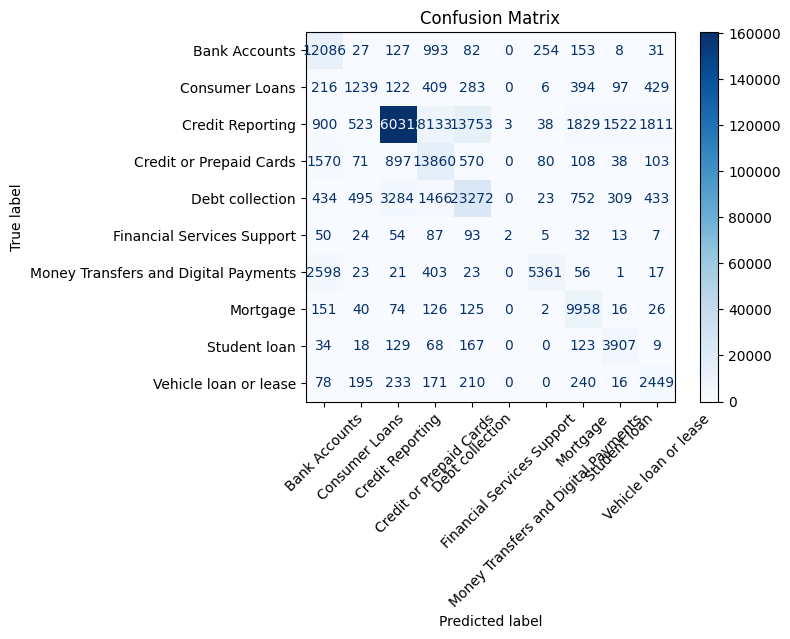

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

Rethinking Financial Services Support Department

In [53]:
pd.crosstab(y_test, y_pred).loc["Financial Services Support"]

col_0
Bank Accounts                           50
Consumer Loans                          24
Credit Reporting                        54
Credit or Prepaid Cards                 87
Debt collection                         93
Financial Services Support               2
Money Transfers and Digital Payments     5
Mortgage                                32
Student loan                            13
Vehicle loan or lease                    7
Name: Financial Services Support, dtype: int64

Remove Financial Services Support Department From Train and Test Sets

In [54]:
train_df = train_df[train_df["Product"] != "Financial Services Support"]
test_df = test_df[test_df["Product"] != "Financial Services Support"]

Sanity Check

In [55]:
print(train_df["Product"].value_counts())
print(test_df["Product"].value_counts())

Product
Credit Reporting                        755296
Debt collection                         121874
Credit or Prepaid Cards                  69186
Bank Accounts                            55046
Mortgage                                 42073
Money Transfers and Digital Payments     34013
Student loan                             17818
Vehicle loan or lease                    14368
Consumer Loans                           12780
Name: count, dtype: int64
Product
Credit Reporting                        188824
Debt collection                          30468
Credit or Prepaid Cards                  17297
Bank Accounts                            13761
Mortgage                                 10518
Money Transfers and Digital Payments      8503
Student loan                              4455
Vehicle loan or lease                     3592
Consumer Loans                            3195
Name: count, dtype: int64


In [56]:
print(train_df.shape)
print(test_df.shape)

(1122454, 3)
(280613, 3)


Retrain Model

In [57]:
X_train = train_df["Consumer complaint narrative"]
y_train = train_df["Product"]

X_test = test_df["Consumer complaint narrative"]
y_test = test_df["Product"]

In [58]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [59]:
y_pred = model.predict(X_test)

In [60]:
print(classification_report(y_test, y_pred))

                                      precision    recall  f1-score   support

                       Bank Accounts       0.67      0.88      0.76     13761
                      Consumer Loans       0.47      0.39      0.42      3195
                    Credit Reporting       0.97      0.85      0.91    188824
             Credit or Prepaid Cards       0.54      0.80      0.65     17297
                     Debt collection       0.60      0.76      0.68     30468
Money Transfers and Digital Payments       0.93      0.63      0.75      8503
                            Mortgage       0.73      0.95      0.83     10518
                        Student loan       0.66      0.88      0.75      4455
               Vehicle loan or lease       0.46      0.68      0.55      3592

                            accuracy                           0.83    280613
                           macro avg       0.67      0.76      0.70    280613
                        weighted avg       0.86      0.83     

Save cleaned data

In [61]:
train_df.to_parquet("data/processed/train_split_no_fss.parquet", index=False)
test_df.to_parquet("data/processed/test_split_no_fss.parquet", index=False)